<a href="https://colab.research.google.com/github/Lobnaait/SEARCH_Lobna_Tsetline_CMRI/blob/main/DNN_ACDCdatset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
from huggingface_hub import snapshot_download
data_dir = snapshot_download(repo_id="mathpluscode/ACDC", allow_patterns=["*.nii.gz", "*.csv"], repo_type="dataset")
!ls /root/.cache/huggingface/hub/datasets--mathpluscode--ACDC/snapshots/4a312b610f395eda5dc0aa36f087dd6ca9991e41/
!pip install -q torch

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 752 files:   0%|          | 0/752 [00:00<?, ?it/s]

test  test.csv	train  train.csv


In [19]:
#IMPORT LIBRARIES
import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, auc, roc_auc_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [20]:
#EXTRACT DATASET
import os

train = pd.read_csv(os.path.join(data_dir, "train.csv"))
test = pd.read_csv(os.path.join(data_dir, "test.csv"))

print(train.shape)
print(test.shape)

train.head(10)

(100, 15)
(50, 15)


,pid,pathology,height,weight,bmi,n_frames,ed_frame,es_frame,original_sax_spacing_x,original_sax_spacing_y,original_sax_spacing_z,n_slices,edv,esv,ef
0,patient001,DCM,1.84,95.0,28.060019,30,1,12,1.562500,1.562500,10.0,10,1354.58,1125.97,16.876818
1,patient002,DCM,1.60,70.0,27.343750,30,1,12,1.367188,1.367188,10.0,10,1212.69,979.53,19.226678
2,patient003,DCM,1.65,77.0,28.282828,30,1,15,1.562500,1.562500,10.0,10,1405.42,1298.96,7.574960
3,patient004,DCM,1.59,46.0,18.195483,28,1,15,1.367188,1.367188,10.0,10,1226.58,1114.83,9.110698
4,patient005,DCM,1.65,77.0,28.282828,30,1,13,1.406250,1.406250,10.0,10,1446.55,1211.36,16.258684
5,patient006,DCM,1.80,70.0,21.604938,28,1,16,1.757812,1.757812,10.0,11,1637.74,1374.18,16.092909
6,patient007,DCM,1.73,107.0,35.751278,16,1,7,1.875000,1.875000,10.0,10,1589.67,1411.75,11.192260
7,patient008,DCM,1.80,100.0,30.864198,28,1,13,1.562500,1.562500,10.0,10,1332.23,1158.90,13.010516
8,patient009,DCM,1.53,61.0,26.058354,35,1,13,1.367190,1.367190,10.0,10,1254.25,1154.37,7.963325
9,patient010,DCM,1.70,68.0,23.529412,28,1,13,1.562500,1.562500,10.0,10,1484.35,1316.59,11.301917


In [21]:
TARGET = "pathology"
print(train[TARGET].value_counts())

pathology
DCM     20
HCM     20
MINF    20
NOR     20
RV      20
Name: count, dtype: int64


In [22]:
# EXTRACT TRAINING SET AND VALIDATION SET
print(train.columns.tolist())
features = train.columns.tolist()
features.remove(TARGET)
features.remove('pid')
print(features)

print("\n ")
X = train[features].copy()
y = train[TARGET].copy()

print("X_train shape:", X.shape)
print("y_train shape:", y.shape)
print("\nClasses:", y.value_counts())


['pid', 'pathology', 'height', 'weight', 'bmi', 'n_frames', 'ed_frame', 'es_frame', 'original_sax_spacing_x', 'original_sax_spacing_y', 'original_sax_spacing_z', 'n_slices', 'edv', 'esv', 'ef']
['height', 'weight', 'bmi', 'n_frames', 'ed_frame', 'es_frame', 'original_sax_spacing_x', 'original_sax_spacing_y', 'original_sax_spacing_z', 'n_slices', 'edv', 'esv', 'ef']

 
X_train shape: (100, 13)
y_train shape: (100,)

Classes: pathology
DCM     20
HCM     20
MINF    20
NOR     20
RV      20
Name: count, dtype: int64


In [23]:
# EXTRACT TEST SET
features = test.columns.tolist()
features.remove(TARGET)
features.remove('pid')

X_test = test[features].copy()
y_test = test[TARGET].copy()

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("\nClasses:", y_test.value_counts())

X_test shape: (50, 13)
y_test shape: (50,)

Classes: pathology
DCM     10
NOR     10
MINF    10
HCM     10
RV      10
Name: count, dtype: int64


In [24]:
# ---------------------------------------------------------
# DNN classifier
# A small feed-forward network with configurable hidden width.
# ---------------------------------------------------------
class ACDCClassifier(nn.Module):
    def __init__(self, n_features, n_classes, hidden_dim=64, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, n_classes),
        )

    def forward(self, x):
        return self.net(x)


In [25]:
# ---------------------------------------------------------
# Train/evaluate helper
# (plays the role that .fit()/.predict() played for the Tsetlin Machine)
# ---------------------------------------------------------
def train_dnn(X_train, y_train, X_val, y_val, n_classes,
              hidden_dim=64, epochs=100, lr=1e-3, batch_size=32, dropout=0.3):

    train_ds = TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).long())
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    X_val_t = torch.from_numpy(X_val).float().to(device)

    model = ACDCClassifier(X_train.shape[1], n_classes, hidden_dim=hidden_dim, dropout=dropout).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    best_macro_f1, best_state = -1.0, None
    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            opt.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(X_val_t).argmax(1).cpu().numpy()
        macro_f1 = f1_score(y_val, val_preds, average="macro")
        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_t).argmax(1).cpu().numpy()
    return model, val_preds


In [26]:
# Reproducible split
X_train, X_validation, y_train, y_validation = train_test_split(X, y, test_size=0.25, stratify=y, random_state=SEED)

# Convert pandas dataframes to NumPy
X_train_np = X_train.to_numpy(dtype=np.float32)
X_validation_np = X_validation.to_numpy(dtype=np.float32)
X_test_np = X_test.to_numpy(dtype=np.float32)

# Encode class labels as integers
label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_validation_enc = label_encoder.transform(y_validation)
y_test_enc = label_encoder.transform(y_test)

N_CLASSES = len(label_encoder.classes_)


In [27]:
# ---------------------------------------------------------
# Find optimal hidden layer width
# (plays the role that "optimal number of thresholds" played for the TM)
# ---------------------------------------------------------

hidden_dim_candidates = [8, 16, 32, 64, 128, 256]

results = []

for hidden_dim in hidden_dim_candidates:
    # IMPORTANT:
    # scaler is fit ONLY on training data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_np)
    X_validation_scaled = scaler.transform(X_validation_np)

    # DNN
    model, predictions = train_dnn(
        X_train_scaled, y_train_enc,
        X_validation_scaled, y_validation_enc,
        n_classes=N_CLASSES, hidden_dim=hidden_dim, epochs=100,
    )

    accuracy = accuracy_score(y_validation_enc, predictions)
    macro_f1 = f1_score(y_validation_enc, predictions, average="macro")

    results.append({
        "hidden_dim": hidden_dim,
        "n_features": X_train_scaled.shape[1],
        "accuracy": accuracy,
        "macro_f1": macro_f1,
    })
    print(f"Hidden dim: {hidden_dim:3d} | accuracy: {accuracy:.4f} | Macro F1: {macro_f1:.4f}")


Hidden dim:   8 | accuracy: 0.5200 | Macro F1: 0.5157
Hidden dim:  16 | accuracy: 0.7600 | Macro F1: 0.7328
Hidden dim:  32 | accuracy: 0.8400 | Macro F1: 0.8372
Hidden dim:  64 | accuracy: 0.7600 | Macro F1: 0.7468
Hidden dim: 128 | accuracy: 0.7600 | Macro F1: 0.7709
Hidden dim: 256 | accuracy: 0.7600 | Macro F1: 0.7599


In [28]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="macro_f1", ascending=False).reset_index(drop=True)

print(results_df)

best_hidden_dim = int(results_df.loc[results_df["macro_f1"].idxmax(),"hidden_dim" ])

print("Optimal hidden layer width:", best_hidden_dim)


   hidden_dim  n_features  accuracy  macro_f1
0          32          13      0.84  0.837179
1         128          13      0.76  0.770855
2         256          13      0.76  0.759899
3          64          13      0.76  0.746775
4          16          13      0.76  0.732756
5           8          13      0.52  0.515714
Optimal hidden layer width: 32


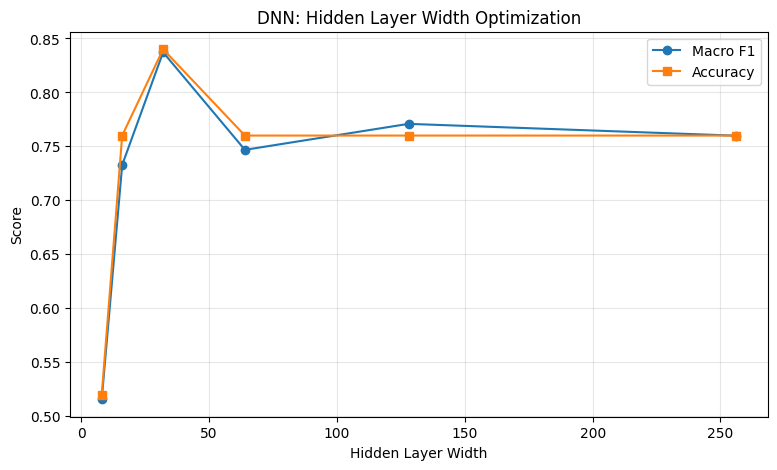

In [29]:
import matplotlib.pyplot as plt

results_sorted = results_df.sort_values("hidden_dim")

plt.figure(figsize=(9, 5))

plt.plot(
    results_sorted["hidden_dim"],
    results_sorted["macro_f1"],
    marker="o",
    label="Macro F1"
)

plt.plot(
    results_sorted["hidden_dim"],
    results_sorted["accuracy"],
    marker="s",
    label="Accuracy"
)

plt.xlabel("Hidden Layer Width")
plt.ylabel("Score")
plt.title("DNN: Hidden Layer Width Optimization")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


In [30]:
X_train_full = np.vstack([X_train_np, X_validation_np])
y_train_full = np.concatenate([y_train_enc, y_validation_enc])

# Recalculate scaling using ALL training data
final_scaler = StandardScaler()
X_train_full_scaled = final_scaler.fit_transform(X_train_full)
X_test_scaled = final_scaler.transform(X_test_np)

print("Final training shape:", X_train_full_scaled.shape)
print("Final test shape:", X_test_scaled.shape)

final_model, _ = train_dnn(
    X_train_full_scaled, y_train_full,
    X_test_scaled, y_test_enc,   # used only to track the best epoch by macro F1, same role val set played above
    n_classes=N_CLASSES, hidden_dim=best_hidden_dim, epochs=100,
)

final_model.eval()
with torch.no_grad():
    test_predictions = final_model(torch.from_numpy(X_test_scaled).float().to(device)).argmax(1).cpu().numpy()


Final training shape: (100, 13)
Final test shape: (50, 13)


In [31]:
print("Test Accuracy:", accuracy_score(y_test_enc, test_predictions))
print("Test Macro F1:", f1_score(y_test_enc, test_predictions, average="macro"))
print("\nClassification Report:")
print(classification_report(y_test_enc, test_predictions, target_names=label_encoder.classes_))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_enc, test_predictions))


Test Accuracy: 0.62
Test Macro F1: 0.6181758744687806

Classification Report:
              precision    recall  f1-score   support

         DCM       0.69      0.90      0.78        10
         HCM       0.43      0.60      0.50        10
        MINF       1.00      0.40      0.57        10
         NOR       0.50      0.50      0.50        10
          RV       0.78      0.70      0.74        10

    accuracy                           0.62        50
   macro avg       0.68      0.62      0.62        50
weighted avg       0.68      0.62      0.62        50


Confusion Matrix:
[[9 1 0 0 0]
 [1 6 0 3 0]
 [3 3 4 0 0]
 [0 3 0 5 2]
 [0 1 0 2 7]]


In [32]:
# Riepilogo: "media +/- deviazione standard" per ogni malattia
def fmt(mean_arr, std_arr):
    return [f"{m:.4f} \u00b1 {s:.4f}" for m, s in zip(mean_arr, std_arr)]

summary = pd.DataFrame({
    "precision": fmt(precision_folds.mean(axis=0), precision_folds.std(axis=0)),
    "recall":    fmt(recall_folds.mean(axis=0), recall_folds.std(axis=0)),
    "f1-score":  fmt(f1_folds.mean(axis=0), f1_folds.std(axis=0)),
}, index=class_names)

print(f"Cross-validation a {N_SPLITS} fold \u2014 valore \u00b1 deviazione standard per classe:\n")
print(summary)


Cross-validation a 5 fold — valore ± deviazione standard per classe:

            precision           recall         f1-score
DCM   0.7498 ± 0.1543  0.8333 ± 0.1826  0.7784 ± 0.1392
HCM   0.4433 ± 0.2768  0.5333 ± 0.3232  0.4769 ± 0.2826
MINF  0.5667 ± 0.1333  0.5000 ± 0.2108  0.5210 ± 0.1697
NOR   0.4750 ± 0.2784  0.4333 ± 0.2261  0.4400 ± 0.2290
RV    0.6767 ± 0.1020  0.6333 ± 0.2211  0.6388 ± 0.1365
